# Эксперимент 01: Разведочный анализ данных (EDA)

## Цель
Изучить распределения признаков, выявить корреляции с целевой переменной и обосновать выбор метрик для моделирования.

## Данные
- Файл: `data/processed/employee_burnout_processed.csv`
- Размер: 22 750 строк, 10 признаков + целевая переменная

## Ключевые вопросы
- Есть ли дисбаланс классов?
- Какие признаки сильнее всего коррелируют с выгоранием?
- Эффективны ли наши кастомные признаки (`tenure_months`, `fatigue_resource_ratio`)?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
warnings.filterwarnings('ignore')

print("Библиотеки импортированы")

Библиотеки импортированы


In [2]:
df = pd.read_csv("../data/processed/employee_burnout_processed.csv")

print(f"Датасет загружен: {df.shape[0]} строк, {df.shape[1]} колонок")
print(f"\nКолонки: {df.columns.tolist()}")
df.head()

Датасет загружен: 22750 строк, 11 колонок

Колонки: ['gender', 'company_type', 'wfh_setup_available', 'designation', 'resource_allocation', 'mental_fatigue_score', 'tenure_months', 'fatigue_resource_ratio', 'is_senior', 'high_workload', 'burnout_target']


,gender,company_type,wfh_setup_available,designation,resource_allocation,mental_fatigue_score,tenure_months,fatigue_resource_ratio,is_senior,high_workload,burnout_target
0,1,0,0,2,3.0,3.8,27.036794,0.950000,0,0,0
1,0,0,1,1,2.0,5.0,25.032852,1.666667,0,0,0
2,1,1,1,2,4.0,5.8,33.738502,1.160000,0,0,0
3,0,0,1,1,1.0,2.6,25.919842,1.300000,0,0,0
4,1,0,0,3,7.0,6.9,29.270696,0.862500,1,1,1


In [3]:
print("Описательная статистика:\n")
display(df.describe().T)

print("\nИнформация о типах:\n")
df.info()

Описательная статистика:



,count,mean,std,min,25%,50%,75%,max
gender,22750.0,0.523429,0.499462,0.000000,0.000000,1.000000,1.000000,1.000000
company_type,22750.0,0.348000,0.476346,0.000000,0.000000,0.000000,1.000000,1.000000
wfh_setup_available,22750.0,0.540220,0.498391,0.000000,0.000000,1.000000,1.000000,1.000000
designation,22750.0,2.178725,1.135145,0.000000,1.000000,2.000000,3.000000,5.000000
resource_allocation,22750.0,4.452176,1.987427,1.000000,3.000000,4.000000,6.000000,10.000000
mental_fatigue_score,22750.0,5.744176,1.829962,0.000000,4.700000,5.900000,6.900000,10.000000
tenure_months,22750.0,30.013321,3.460847,24.014455,27.036794,29.993430,33.015769,36.005256
fatigue_resource_ratio,22750.0,1.110456,0.373466,0.000000,0.900000,1.055556,1.260000,2.950000
is_senior,22750.0,0.385670,0.486764,0.000000,0.000000,0.000000,1.000000,1.000000
high_workload,22750.0,0.288220,0.452944,0.000000,0.000000,0.000000,1.000000,1.000000



Информация о типах:

<class 'pandas.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  22750 non-null  int64  
 1   company_type            22750 non-null  int64  
 2   wfh_setup_available     22750 non-null  int64  
 3   designation             22750 non-null  int64  
 4   resource_allocation     22750 non-null  float64
 5   mental_fatigue_score    22750 non-null  float64
 6   tenure_months           22750 non-null  float64
 7   fatigue_resource_ratio  22750 non-null  float64
 8   is_senior               22750 non-null  int64  
 9   high_workload           22750 non-null  int64  
 10  burnout_target          22750 non-null  int64  
dtypes: float64(4), int64(7)
memory usage: 1.9 MB


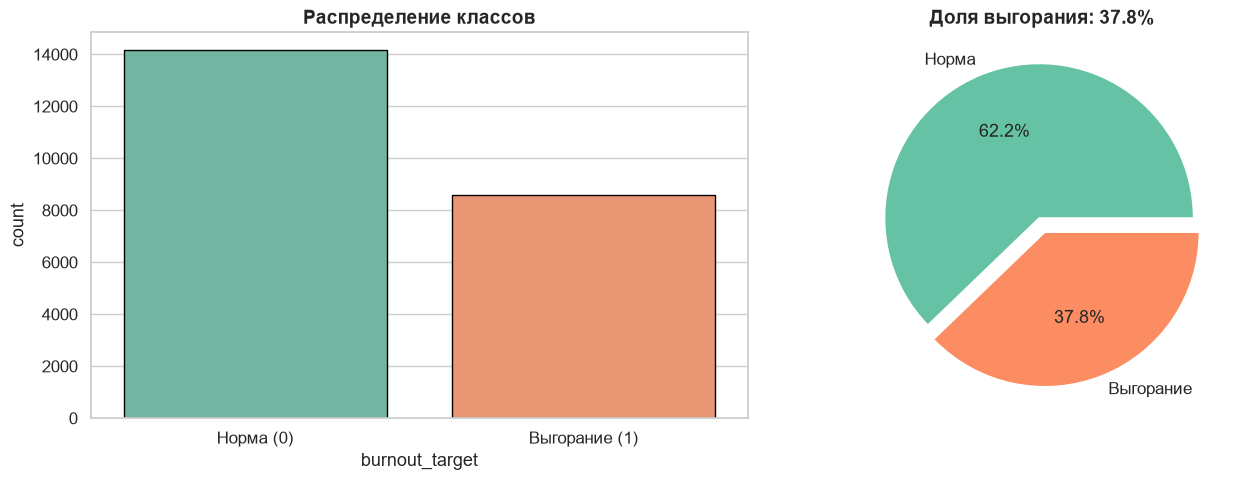

Дисбаланс: Нет


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='burnout_target', data=df, ax=axes[0], palette='Set2', edgecolor='black')
axes[0].set_title('Распределение классов', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['Норма (0)', 'Выгорание (1)'])

burnout_pct = df['burnout_target'].mean() * 100
axes[1].pie([100-burnout_pct, burnout_pct], 
            labels=['Норма', 'Выгорание'], 
            autopct='%1.1f%%', 
            colors=['#66c2a5', '#fc8d62'],
            explode=(0.05, 0.05))
axes[1].set_title(f'Доля выгорания: {burnout_pct:.1f}%', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("../artifacts/class_distribution.png", 
            dpi=300,
            bbox_inches='tight',
            facecolor='white')
plt.show()

print(f"Дисбаланс: {'Да' if burnout_pct < 35 or burnout_pct > 65 else 'Нет'}")

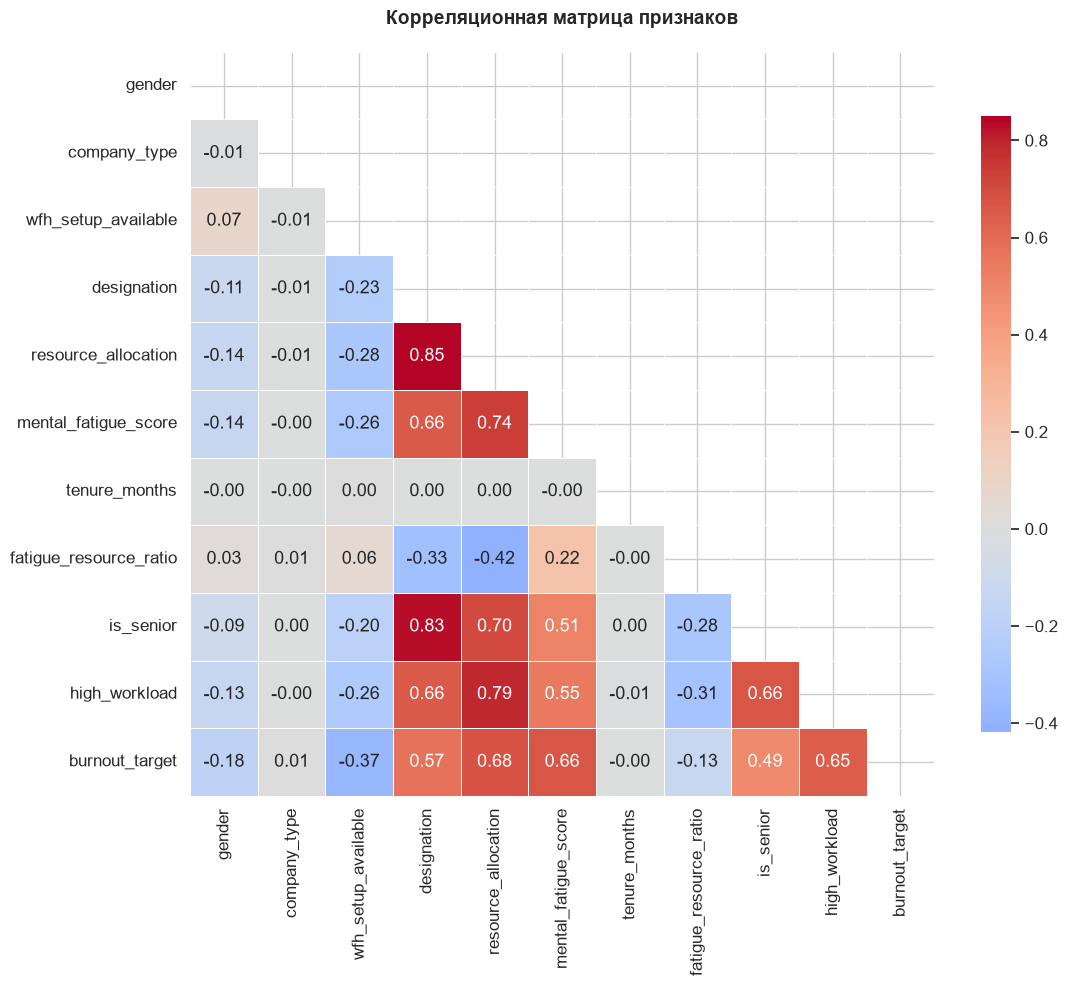

Корреляция с burnout_target:
  resource_allocation           : +0.681
  mental_fatigue_score          : +0.664
  high_workload                 : +0.647
  designation                   : +0.571
  is_senior                     : +0.486
  wfh_setup_available           : -0.373
  gender                        : -0.184
  fatigue_resource_ratio        : -0.129
  company_type                  : +0.005
  tenure_months                 : -0.001


In [5]:
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', 
            fmt=".2f", linewidths=0.5, center=0, square=True,
            cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица признаков', fontsize=14, fontweight='bold', pad=20)
plt.savefig("../artifacts/correlation_matrix.png", 
            dpi=300,
            bbox_inches='tight',
            facecolor='white')
plt.show()

print("Корреляция с burnout_target:")
correlations = df.corr()['burnout_target'].drop('burnout_target').sort_values(key=abs, ascending=False)
for feat, corr in correlations.items():
    print(f"  {feat:30s}: {corr:+.3f}")

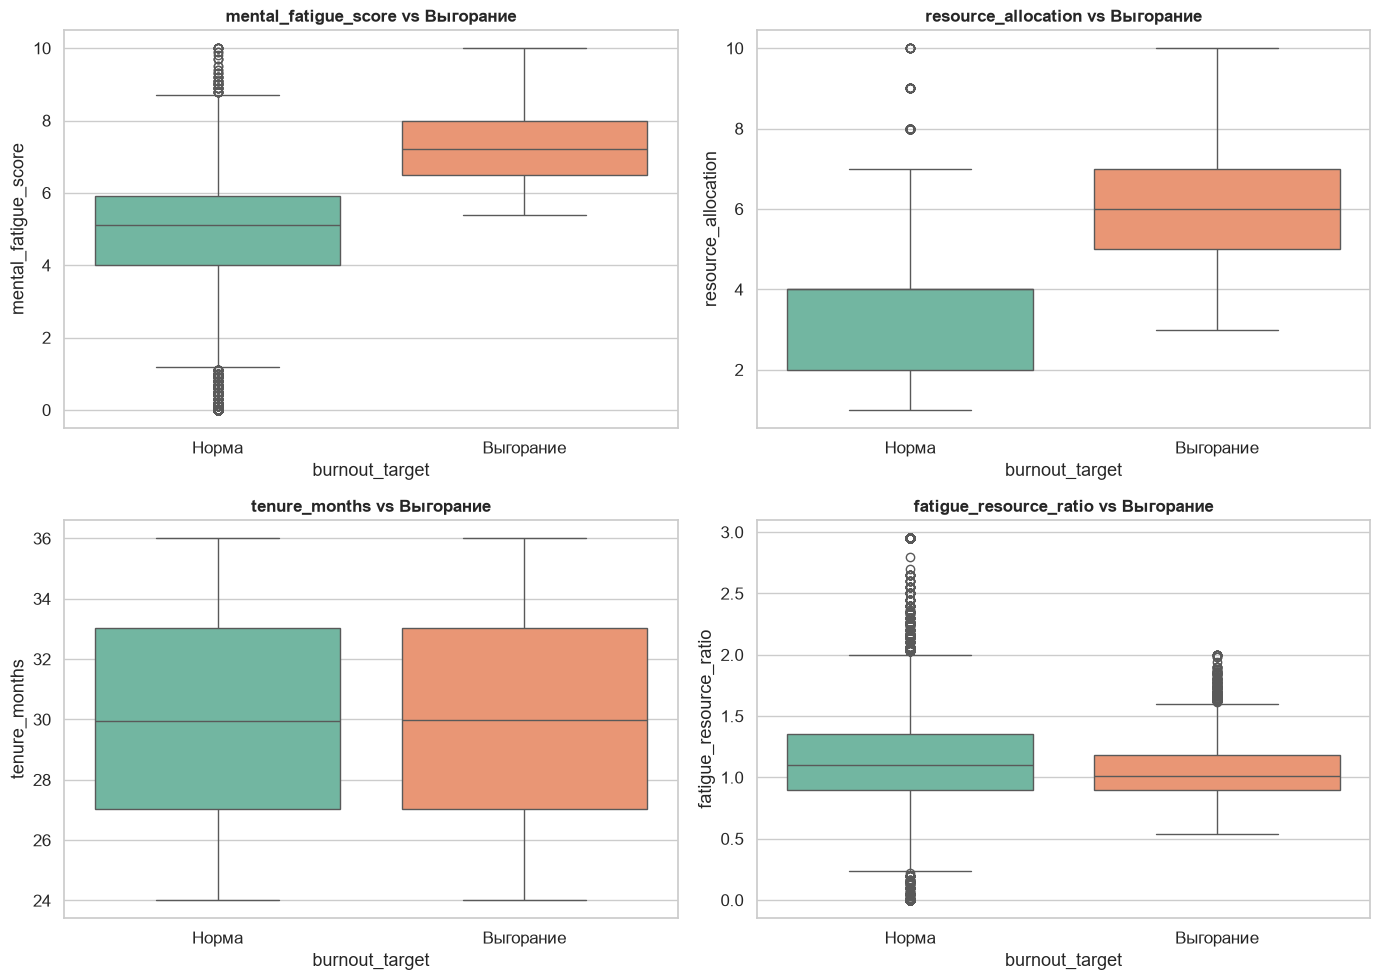

Рисунок сохранён в artifacts/boxplots.png


In [6]:
key_features = ['mental_fatigue_score', 'resource_allocation', 
                'tenure_months', 'fatigue_resource_ratio']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feat in enumerate(key_features):
    sns.boxplot(x='burnout_target', y=feat, data=df, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{feat} vs Выгорание', fontsize=12, fontweight='bold')
    axes[idx].set_xticklabels(['Норма', 'Выгорание'])

plt.tight_layout()
plt.savefig("../artifacts/boxplots.png", 
            dpi=300,
            bbox_inches='tight',
            facecolor='white')
plt.show()

print("Рисунок сохранён в artifacts/boxplots.png")

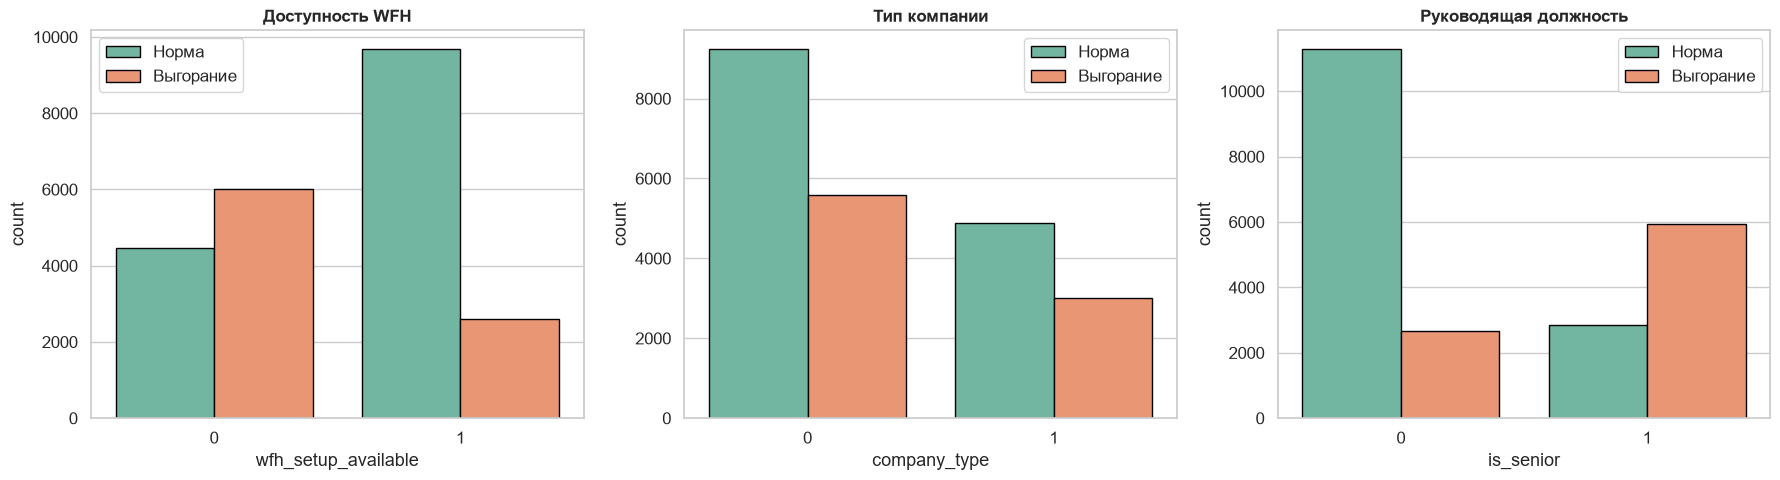

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (feat, title) in enumerate([
    ('wfh_setup_available', 'Доступность WFH'),
    ('company_type', 'Тип компании'),
    ('is_senior', 'Руководящая должность')
]):
    sns.countplot(x=feat, hue='burnout_target', data=df, ax=axes[idx], 
                  palette='Set2', edgecolor='black')
    axes[idx].set_title(title, fontsize=12, fontweight='bold')
    axes[idx].legend(['Норма', 'Выгорание'])

plt.tight_layout()
plt.savefig("../artifacts/categorical.png", 
            dpi=300,
            bbox_inches='tight',
            facecolor='white')
plt.show()

Средние значения признаков по классам:



burnout_target,0,1
gender,0.594912,0.405814
company_type,0.346078,0.351163
wfh_setup_available,0.685300,0.301512
designation,1.673852,3.009419
resource_allocation,3.397668,6.187209
mental_fatigue_score,4.797413,7.301930
tenure_months,30.016660,30.007827
fatigue_resource_ratio,1.148000,1.048682
is_senior,0.201131,0.689302
high_workload,0.059859,0.663953


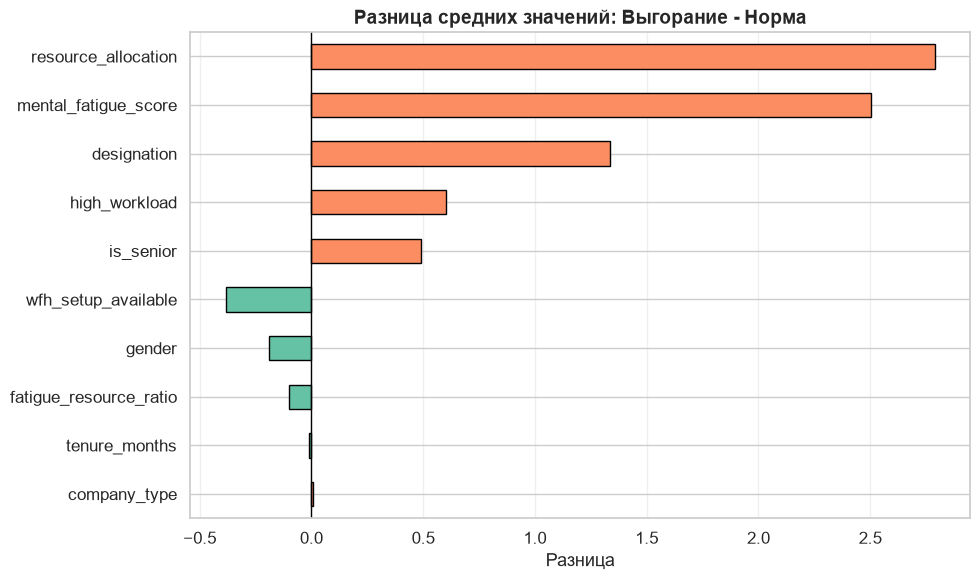

In [8]:
comparison = df.groupby('burnout_target').mean()
print("Средние значения признаков по классам:\n")
display(comparison.T)

plt.figure(figsize=(10, 6))
diff = comparison.iloc[1] - comparison.iloc[0]
diff_sorted = diff.sort_values(key=abs, ascending=True)

colors = ['#fc8d62' if v > 0 else '#66c2a5' for v in diff_sorted]
diff_sorted.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Разница средних значений: Выгорание - Норма', fontsize=14, fontweight='bold')
plt.xlabel('Разница')
plt.axvline(0, color='black', linewidth=1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("../artifacts/mean_difference.png", 
            dpi=300,
            bbox_inches='tight',
            facecolor='white')
plt.show()

## Итоги разведочного анализа

### Качество данных
- Датасет: 22 750 строк, 11 колонок (10 признаков + таргет)
- Пропуски заполнены, все признаки числовые
- Созданы 4 новых признака: `tenure_months`, `fatigue_resource_ratio`, `is_senior`, `high_workload`

### Распределение классов
- Классы сбалансированы (62.2/37.8)

### Корреляции с целевой переменной

**Сильные признаки:**
- `resource_allocation`: +0.681
- `mental_fatigue_score`: +0.664
- `designation`: +0.571
- `wfh_setup_available`: -0.373

**Слабые признаки:**
- `fatigue_resource_ratio`: -0.129
- `tenure_months`: -0.001
- `company_type`: +0.005

### Ключевые выводы
- Высокая нагрузка (`resource_allocation`) и ментальная усталость — основные факторы выгорания
- Руководители (`designation` ≥ 3) выгорают чаще
- Удаленная работа снижает риск выгорания
- Кастомный признак `fatigue_resource_ratio` не усилил предсказательную силу из-за положительной корреляции `resource_allocation` с выгоранием
- Стаж и тип компании не влияют на выгорание в данном датасете